# Bài 2: Cây quyết định ID3 – dữ liệu rủi ro tín dụng
Dự đoán khách hàng vay có rủi ro tín dụng hay không (`1` = có rủi ro, `0` = không) dựa trên độ tuổi, tình trạng hôn nhân, sở hữu bất động sản và thu nhập.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dữ liệu và rời rạc hóa
15 mẫu, nhãn gồm 9 mẫu `1` và 6 mẫu `0`. ID3 chỉ làm việc với thuộc tính rời rạc, nên 2 thuộc tính số được chia nhóm:
- **Độ tuổi:** `<30`, `30–39`, `>=40`
- **Thu nhập:** `<8tr`, `8–<12tr`, `>=12tr`

In [2]:
rows = [
    (1, 25, 'Độc thân', 'Ở cùng bố mẹ', 7000000, 0),
    (2, 40, 'Đã kết hôn', 'Nhà sở hữu', 18000000, 0),
    (3, 35, 'Từng ly hôn', 'Nhà thuê', 12000000, 1),
    (4, 27, 'Đã kết hôn', 'Ở cùng bố mẹ', 9000000, 1),
    (5, 31, 'Độc thân', 'Nhà thuê', 6000000, 1),
    (6, 36, 'Đã kết hôn', 'Nhà sở hữu', 8000000, 1),
    (7, 48, 'Độc thân', 'Nhà thuê', 7000000, 0),
    (8, 26, 'Đã kết hôn', 'Nhà thuê', 8000000, 1),
    (9, 33, 'Từng ly hôn', 'Ở cùng bố mẹ', 5000000, 1),
    (10, 29, 'Độc thân', 'Nhà thuê', 10000000, 0),
    (11, 38, 'Đã kết hôn', 'Nhà sở hữu', 15000000, 0),
    (12, 44, 'Độc thân', 'Nhà sở hữu', 14000000, 1),
    (13, 42, 'Đã kết hôn', 'Nhà sở hữu', 10000000, 0),
    (14, 28, 'Độc thân', 'Nhà thuê', 7000000, 1),
    (15, 30, 'Đã kết hôn', 'Ở cùng bố mẹ', 6000000, 1)
]
raw = pd.DataFrame(rows, columns=["ID", "Độ tuổi", "Hôn nhân", "Sở hữu BĐS", "Thu nhập", "Rủi ro tín dụng"])
print("Dữ liệu gốc:")
print(raw.to_string(index=False))

# ----- Rời rạc hóa 2 thuộc tính số -----
def nhom_tuoi(a):
    return "<30" if a < 30 else ("30–39" if a < 40 else ">=40")

def nhom_thu_nhap(x):
    return "<8tr" if x < 8_000_000 else ("8–<12tr" if x < 12_000_000 else ">=12tr")

data = raw.drop(columns="ID").copy()          # bỏ cột ID khỏi các thuộc tính
data["Độ tuổi"] = raw["Độ tuổi"].apply(nhom_tuoi)
data["Thu nhập"] = raw["Thu nhập"].apply(nhom_thu_nhap)
data.index = raw["ID"]

TARGET = "Rủi ro tín dụng"
ATTRS = ["Độ tuổi", "Hôn nhân", "Sở hữu BĐS", "Thu nhập"]
ORDERS = {'Độ tuổi': ['<30', '30–39', '>=40'], 'Hôn nhân': ['Độc thân', 'Đã kết hôn', 'Từng ly hôn'], 'Sở hữu BĐS': ['Ở cùng bố mẹ', 'Nhà thuê', 'Nhà sở hữu'], 'Thu nhập': ['<8tr', '8–<12tr', '>=12tr']}
print("\nDữ liệu sau khi rời rạc hóa:")
data

Dữ liệu gốc:
 ID  Độ tuổi    Hôn nhân   Sở hữu BĐS  Thu nhập  Rủi ro tín dụng
  1       25    Độc thân Ở cùng bố mẹ   7000000                0
  2       40  Đã kết hôn   Nhà sở hữu  18000000                0
  3       35 Từng ly hôn     Nhà thuê  12000000                1
  4       27  Đã kết hôn Ở cùng bố mẹ   9000000                1
  5       31    Độc thân     Nhà thuê   6000000                1
  6       36  Đã kết hôn   Nhà sở hữu   8000000                1
  7       48    Độc thân     Nhà thuê   7000000                0
  8       26  Đã kết hôn     Nhà thuê   8000000                1
  9       33 Từng ly hôn Ở cùng bố mẹ   5000000                1
 10       29    Độc thân     Nhà thuê  10000000                0
 11       38  Đã kết hôn   Nhà sở hữu  15000000                0
 12       44    Độc thân   Nhà sở hữu  14000000                1
 13       42  Đã kết hôn   Nhà sở hữu  10000000                0
 14       28    Độc thân     Nhà thuê   7000000                1
 15       30

,Độ tuổi,Hôn nhân,Sở hữu BĐS,Thu nhập,Rủi ro tín dụng
ID,,,,,
1,<30,Độc thân,Ở cùng bố mẹ,<8tr,0
2,>=40,Đã kết hôn,Nhà sở hữu,>=12tr,0
3,30–39,Từng ly hôn,Nhà thuê,>=12tr,1
4,<30,Đã kết hôn,Ở cùng bố mẹ,8–<12tr,1
5,30–39,Độc thân,Nhà thuê,<8tr,1
6,30–39,Đã kết hôn,Nhà sở hữu,8–<12tr,1
7,>=40,Độc thân,Nhà thuê,<8tr,0
8,<30,Đã kết hôn,Nhà thuê,8–<12tr,1
9,30–39,Từng ly hôn,Ở cùng bố mẹ,<8tr,1


## Lời giải tay
Công thức:

$$Entropy(S) = -\sum_i p_i \log_2 p_i \qquad Gain(S, A) = Entropy(S) - \sum_{v} \frac{|S_v|}{|S|} Entropy(S_v)$$

Các bước 1–4: tính Entropy, lập bảng đếm và tính Gain cho từng thuộc tính, chọn thuộc tính có Gain lớn nhất, rồi lặp lại cho từng nhánh con.

#### Nút: Toàn bộ tập dữ liệu (15 mẫu: 9 × 1, 6 × 0)
$$Entropy(S) = -\frac{9}{15}\log_2\frac{9}{15} - \frac{6}{15}\log_2\frac{6}{15} = 0.971$$

**Thuộc tính Độ tuổi**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| <30 | 3 | 2 | 5 | 0.971 |
| 30–39 | 5 | 1 | 6 | 0.650 |
| >=40 | 1 | 3 | 4 | 0.811 |

$$Gain(S, \text{Độ tuổi}) = 0.971 - (\frac{5}{15}\cdot0.971 + \frac{6}{15}\cdot0.650 + \frac{4}{15}\cdot0.811) = 0.171$$

**Thuộc tính Hôn nhân**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Độc thân | 3 | 3 | 6 | 1.000 |
| Đã kết hôn | 4 | 3 | 7 | 0.985 |
| Từng ly hôn | 2 | 0 | 2 | -0.000 |

$$Gain(S, \text{Hôn nhân}) = 0.971 - (\frac{6}{15}\cdot1.000 + \frac{7}{15}\cdot0.985 + \frac{2}{15}\cdot-0.000) = 0.111$$

**Thuộc tính Sở hữu BĐS**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Ở cùng bố mẹ | 3 | 1 | 4 | 0.811 |
| Nhà thuê | 4 | 2 | 6 | 0.918 |
| Nhà sở hữu | 2 | 3 | 5 | 0.971 |

$$Gain(S, \text{Sở hữu BĐS}) = 0.971 - (\frac{4}{15}\cdot0.811 + \frac{6}{15}\cdot0.918 + \frac{5}{15}\cdot0.971) = 0.064$$

**Thuộc tính Thu nhập**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| <8tr | 4 | 2 | 6 | 0.918 |
| 8–<12tr | 3 | 2 | 5 | 0.971 |
| >=12tr | 2 | 2 | 4 | 1.000 |

$$Gain(S, \text{Thu nhập}) = 0.971 - (\frac{6}{15}\cdot0.918 + \frac{5}{15}\cdot0.971 + \frac{4}{15}\cdot1.000) = 0.013$$

⇒ Gain lớn nhất: **Độ tuổi = 0.171** ⇒ chọn **Độ tuổi** để chia nút.

#### Nút: Độ tuổi = <30 (5 mẫu: 3 × 1, 2 × 0)
$$Entropy(S) = -\frac{3}{5}\log_2\frac{3}{5} - \frac{2}{5}\log_2\frac{2}{5} = 0.971$$

**Thuộc tính Hôn nhân**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Độc thân | 1 | 2 | 3 | 0.918 |
| Đã kết hôn | 2 | 0 | 2 | -0.000 |

$$Gain(S, \text{Hôn nhân}) = 0.971 - (\frac{3}{5}\cdot0.918 + \frac{2}{5}\cdot-0.000) = 0.420$$

**Thuộc tính Sở hữu BĐS**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Ở cùng bố mẹ | 1 | 1 | 2 | 1.000 |
| Nhà thuê | 2 | 1 | 3 | 0.918 |

$$Gain(S, \text{Sở hữu BĐS}) = 0.971 - (\frac{2}{5}\cdot1.000 + \frac{3}{5}\cdot0.918) = 0.020$$

**Thuộc tính Thu nhập**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| <8tr | 1 | 1 | 2 | 1.000 |
| 8–<12tr | 2 | 1 | 3 | 0.918 |

$$Gain(S, \text{Thu nhập}) = 0.971 - (\frac{2}{5}\cdot1.000 + \frac{3}{5}\cdot0.918) = 0.020$$

⇒ Gain lớn nhất: **Hôn nhân = 0.420** ⇒ chọn **Hôn nhân** để chia nút.

#### Nút: Độ tuổi = <30 ∧ Hôn nhân = Độc thân (3 mẫu: 1 × 1, 2 × 0)
$$Entropy(S) = -\frac{1}{3}\log_2\frac{1}{3} - \frac{2}{3}\log_2\frac{2}{3} = 0.918$$

**Thuộc tính Sở hữu BĐS**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Ở cùng bố mẹ | 0 | 1 | 1 | -0.000 |
| Nhà thuê | 1 | 1 | 2 | 1.000 |

$$Gain(S, \text{Sở hữu BĐS}) = 0.918 - (\frac{1}{3}\cdot-0.000 + \frac{2}{3}\cdot1.000) = 0.252$$

**Thuộc tính Thu nhập**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| <8tr | 1 | 1 | 2 | 1.000 |
| 8–<12tr | 0 | 1 | 1 | -0.000 |

$$Gain(S, \text{Thu nhập}) = 0.918 - (\frac{2}{3}\cdot1.000 + \frac{1}{3}\cdot-0.000) = 0.252$$

⇒ Gain lớn nhất: **Sở hữu BĐS = 0.252** (bằng Gain với Thu nhập ⇒ chọn thuộc tính đứng trước) ⇒ chọn **Sở hữu BĐS** để chia nút.

#### Nút: Độ tuổi = <30 ∧ Hôn nhân = Độc thân ∧ Sở hữu BĐS = Ở cùng bố mẹ (1 mẫu: 0 × 1, 1 × 0)
Nút thuần nhất ⇒ **lá: 0**

#### Nút: Độ tuổi = <30 ∧ Hôn nhân = Độc thân ∧ Sở hữu BĐS = Nhà thuê (2 mẫu: 1 × 1, 1 × 0)
$$Entropy(S) = -\frac{1}{2}\log_2\frac{1}{2} - \frac{1}{2}\log_2\frac{1}{2} = 1.000$$

**Thuộc tính Thu nhập**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| <8tr | 1 | 0 | 1 | -0.000 |
| 8–<12tr | 0 | 1 | 1 | -0.000 |

$$Gain(S, \text{Thu nhập}) = 1.000 - (\frac{1}{2}\cdot-0.000 + \frac{1}{2}\cdot-0.000) = 1.000$$

⇒ Gain lớn nhất: **Thu nhập = 1.000** ⇒ chọn **Thu nhập** để chia nút.

#### Nút: Độ tuổi = <30 ∧ Hôn nhân = Độc thân ∧ Sở hữu BĐS = Nhà thuê ∧ Thu nhập = <8tr (1 mẫu: 1 × 1, 0 × 0)
Nút thuần nhất ⇒ **lá: 1**

#### Nút: Độ tuổi = <30 ∧ Hôn nhân = Độc thân ∧ Sở hữu BĐS = Nhà thuê ∧ Thu nhập = 8–<12tr (1 mẫu: 0 × 1, 1 × 0)
Nút thuần nhất ⇒ **lá: 0**

#### Nút: Độ tuổi = <30 ∧ Hôn nhân = Đã kết hôn (2 mẫu: 2 × 1, 0 × 0)
Nút thuần nhất ⇒ **lá: 1**

#### Nút: Độ tuổi = 30–39 (6 mẫu: 5 × 1, 1 × 0)
$$Entropy(S) = -\frac{5}{6}\log_2\frac{5}{6} - \frac{1}{6}\log_2\frac{1}{6} = 0.650$$

**Thuộc tính Hôn nhân**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Độc thân | 1 | 0 | 1 | -0.000 |
| Đã kết hôn | 2 | 1 | 3 | 0.918 |
| Từng ly hôn | 2 | 0 | 2 | -0.000 |

$$Gain(S, \text{Hôn nhân}) = 0.650 - (\frac{1}{6}\cdot-0.000 + \frac{3}{6}\cdot0.918 + \frac{2}{6}\cdot-0.000) = 0.191$$

**Thuộc tính Sở hữu BĐS**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Ở cùng bố mẹ | 2 | 0 | 2 | -0.000 |
| Nhà thuê | 2 | 0 | 2 | -0.000 |
| Nhà sở hữu | 1 | 1 | 2 | 1.000 |

$$Gain(S, \text{Sở hữu BĐS}) = 0.650 - (\frac{2}{6}\cdot-0.000 + \frac{2}{6}\cdot-0.000 + \frac{2}{6}\cdot1.000) = 0.317$$

**Thuộc tính Thu nhập**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| <8tr | 3 | 0 | 3 | -0.000 |
| 8–<12tr | 1 | 0 | 1 | -0.000 |
| >=12tr | 1 | 1 | 2 | 1.000 |

$$Gain(S, \text{Thu nhập}) = 0.650 - (\frac{3}{6}\cdot-0.000 + \frac{1}{6}\cdot-0.000 + \frac{2}{6}\cdot1.000) = 0.317$$

⇒ Gain lớn nhất: **Sở hữu BĐS = 0.317** (bằng Gain với Thu nhập ⇒ chọn thuộc tính đứng trước) ⇒ chọn **Sở hữu BĐS** để chia nút.

#### Nút: Độ tuổi = 30–39 ∧ Sở hữu BĐS = Ở cùng bố mẹ (2 mẫu: 2 × 1, 0 × 0)
Nút thuần nhất ⇒ **lá: 1**

#### Nút: Độ tuổi = 30–39 ∧ Sở hữu BĐS = Nhà thuê (2 mẫu: 2 × 1, 0 × 0)
Nút thuần nhất ⇒ **lá: 1**

#### Nút: Độ tuổi = 30–39 ∧ Sở hữu BĐS = Nhà sở hữu (2 mẫu: 1 × 1, 1 × 0)
$$Entropy(S) = -\frac{1}{2}\log_2\frac{1}{2} - \frac{1}{2}\log_2\frac{1}{2} = 1.000$$

**Thuộc tính Hôn nhân**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Đã kết hôn | 1 | 1 | 2 | 1.000 |

$$Gain(S, \text{Hôn nhân}) = 1.000 - (\frac{2}{2}\cdot1.000) = 0.000$$

**Thuộc tính Thu nhập**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| 8–<12tr | 1 | 0 | 1 | -0.000 |
| >=12tr | 0 | 1 | 1 | -0.000 |

$$Gain(S, \text{Thu nhập}) = 1.000 - (\frac{1}{2}\cdot-0.000 + \frac{1}{2}\cdot-0.000) = 1.000$$

⇒ Gain lớn nhất: **Thu nhập = 1.000** ⇒ chọn **Thu nhập** để chia nút.

#### Nút: Độ tuổi = 30–39 ∧ Sở hữu BĐS = Nhà sở hữu ∧ Thu nhập = 8–<12tr (1 mẫu: 1 × 1, 0 × 0)
Nút thuần nhất ⇒ **lá: 1**

#### Nút: Độ tuổi = 30–39 ∧ Sở hữu BĐS = Nhà sở hữu ∧ Thu nhập = >=12tr (1 mẫu: 0 × 1, 1 × 0)
Nút thuần nhất ⇒ **lá: 0**

#### Nút: Độ tuổi = >=40 (4 mẫu: 1 × 1, 3 × 0)
$$Entropy(S) = -\frac{1}{4}\log_2\frac{1}{4} - \frac{3}{4}\log_2\frac{3}{4} = 0.811$$

**Thuộc tính Hôn nhân**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Độc thân | 1 | 1 | 2 | 1.000 |
| Đã kết hôn | 0 | 2 | 2 | -0.000 |

$$Gain(S, \text{Hôn nhân}) = 0.811 - (\frac{2}{4}\cdot1.000 + \frac{2}{4}\cdot-0.000) = 0.311$$

**Thuộc tính Sở hữu BĐS**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Nhà thuê | 0 | 1 | 1 | -0.000 |
| Nhà sở hữu | 1 | 2 | 3 | 0.918 |

$$Gain(S, \text{Sở hữu BĐS}) = 0.811 - (\frac{1}{4}\cdot-0.000 + \frac{3}{4}\cdot0.918) = 0.123$$

**Thuộc tính Thu nhập**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| <8tr | 0 | 1 | 1 | -0.000 |
| 8–<12tr | 0 | 1 | 1 | -0.000 |
| >=12tr | 1 | 1 | 2 | 1.000 |

$$Gain(S, \text{Thu nhập}) = 0.811 - (\frac{1}{4}\cdot-0.000 + \frac{1}{4}\cdot-0.000 + \frac{2}{4}\cdot1.000) = 0.311$$

⇒ Gain lớn nhất: **Hôn nhân = 0.311** (bằng Gain với Thu nhập ⇒ chọn thuộc tính đứng trước) ⇒ chọn **Hôn nhân** để chia nút.

#### Nút: Độ tuổi = >=40 ∧ Hôn nhân = Độc thân (2 mẫu: 1 × 1, 1 × 0)
$$Entropy(S) = -\frac{1}{2}\log_2\frac{1}{2} - \frac{1}{2}\log_2\frac{1}{2} = 1.000$$

**Thuộc tính Sở hữu BĐS**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| Nhà thuê | 0 | 1 | 1 | -0.000 |
| Nhà sở hữu | 1 | 0 | 1 | -0.000 |

$$Gain(S, \text{Sở hữu BĐS}) = 1.000 - (\frac{1}{2}\cdot-0.000 + \frac{1}{2}\cdot-0.000) = 1.000$$

**Thuộc tính Thu nhập**

| Giá trị | Số mẫu 1 | Số mẫu 0 | Tổng | Entropy |
|---|---|---|---|---|
| <8tr | 0 | 1 | 1 | -0.000 |
| >=12tr | 1 | 0 | 1 | -0.000 |

$$Gain(S, \text{Thu nhập}) = 1.000 - (\frac{1}{2}\cdot-0.000 + \frac{1}{2}\cdot-0.000) = 1.000$$

⇒ Gain lớn nhất: **Sở hữu BĐS = 1.000** (bằng Gain với Thu nhập ⇒ chọn thuộc tính đứng trước) ⇒ chọn **Sở hữu BĐS** để chia nút.

#### Nút: Độ tuổi = >=40 ∧ Hôn nhân = Độc thân ∧ Sở hữu BĐS = Nhà thuê (1 mẫu: 0 × 1, 1 × 0)
Nút thuần nhất ⇒ **lá: 0**

#### Nút: Độ tuổi = >=40 ∧ Hôn nhân = Độc thân ∧ Sở hữu BĐS = Nhà sở hữu (1 mẫu: 1 × 1, 0 × 0)
Nút thuần nhất ⇒ **lá: 1**

#### Nút: Độ tuổi = >=40 ∧ Hôn nhân = Đã kết hôn (2 mẫu: 0 × 1, 2 × 0)
Nút thuần nhất ⇒ **lá: 0**


## Kiểm chứng bằng code
### Cài đặt ID3

In [3]:
# ===== Các hàm của thuật toán ID3 =====
def entropy(y):
    """Entropy(S) = -Σ p_i·log2(p_i)"""
    p = y.value_counts(normalize=True).values
    return float(-(p * np.log2(p)).sum())

def info_gain(df, attr, target):
    """Gain(S, A) = Entropy(S) - Σ |S_v|/|S| · Entropy(S_v)"""
    H_S = entropy(df[target])
    weighted = sum(len(sub) / len(df) * entropy(sub[target]) for _, sub in df.groupby(attr))
    return H_S - weighted

def build_tree(df, attrs, target, path="Gốc", depth=0):
    """Xây cây ID3 đệ quy. Nút lá: {'label': nhãn}; nút trong: {'attr', 'children', 'majority'}."""
    indent = "    " * depth
    majority = df[target].mode()[0]
    # Điều kiện dừng 1: nút thuần nhất
    if df[target].nunique() == 1:
        print(f"{indent}[{path}] thuần nhất -> lá: {df[target].iloc[0]}")
        return {"label": df[target].iloc[0]}
    # Điều kiện dừng 2: hết thuộc tính -> lấy nhãn đa số
    if not attrs:
        print(f"{indent}[{path}] hết thuộc tính -> lá (đa số): {majority}")
        return {"label": majority}
    gains = {a: info_gain(df, a, target) for a in attrs}
    # max() trả về thuộc tính đứng trước nếu Gain bằng nhau
    best = max(attrs, key=lambda a: round(gains[a], 10))
    print(f"{indent}[{path}] n={len(df)}, Entropy={entropy(df[target]):.3f}")
    for a in attrs:
        print(f"{indent}    Gain({a}) = {gains[a]:.3f}" + ("  <-- chọn" if a == best else ""))
    children = {}
    for v in ORDERS[best]:
        sub = df[df[best] == v]
        if len(sub) > 0:
            children[v] = build_tree(sub, [a for a in attrs if a != best], target, f"{best}={v}", depth + 1)
    return {"attr": best, "children": children, "majority": majority}

def predict_one(tree, sample, explain=False):
    """Dự đoán nhãn cho 1 mẫu (dict), có thể in đường đi trên cây."""
    node = tree
    while "label" not in node:
        v = sample[node["attr"]]
        if explain: print(f"  {node['attr']} = {v}")
        if v not in node["children"]:
            if explain: print("  (giá trị chưa gặp khi huấn luyện -> dùng nhãn đa số)")
            return node["majority"]
        node = node["children"][v]
    if explain: print(f"  => Nhãn dự đoán: {node['label']}")
    return node["label"]

def predict(tree, df):
    return [predict_one(tree, row) for row in df.to_dict("records")]

def print_tree(node, indent=""):
    """In cây dạng sơ đồ text."""
    if "label" in node:
        print(f"{indent}-> {node['label']}"); return
    for v, child in node["children"].items():
        if "label" in child:
            print(f"{indent}[{node['attr']} = {v}] -> {child['label']}")
        else:
            print(f"{indent}[{node['attr']} = {v}]")
            print_tree(child, indent + "    ")

def extract_rules(node, conds=None):
    """Rút tập luật IF-THEN từ cây."""
    conds = conds or []
    if "label" in node:
        return [(conds, node["label"])]
    rules = []
    for v, child in node["children"].items():
        rules += extract_rules(child, conds + [f"{node['attr']} = {v}"])
    return rules

### Bước 1–3: Entropy và Information Gain tại nút gốc

In [4]:
H_S = entropy(data[TARGET])
print(f"Entropy(S) = {H_S:.3f}\n")
gain_table = pd.DataFrame({"Thuộc tính": ATTRS, "Gain": [round(info_gain(data, a, TARGET), 3) for a in ATTRS]})
print(gain_table.sort_values("Gain", ascending=False).to_string(index=False))
print("\n=> Nút gốc:", max(ATTRS, key=lambda a: round(info_gain(data, a, TARGET), 10)))

Entropy(S) = 0.971

Thuộc tính  Gain
   Độ tuổi 0.171
  Hôn nhân 0.111
Sở hữu BĐS 0.064
  Thu nhập 0.013

=> Nút gốc: Độ tuổi


### Bước 4: Xây dựng cây đệ quy (in Entropy và Gain ở mỗi bước)

In [5]:
tree = build_tree(data, ATTRS, TARGET)

[Gốc] n=15, Entropy=0.971
    Gain(Độ tuổi) = 0.171  <-- chọn
    Gain(Hôn nhân) = 0.111
    Gain(Sở hữu BĐS) = 0.064
    Gain(Thu nhập) = 0.013
    [Độ tuổi=<30] n=5, Entropy=0.971
        Gain(Hôn nhân) = 0.420  <-- chọn
        Gain(Sở hữu BĐS) = 0.020
        Gain(Thu nhập) = 0.020
        [Hôn nhân=Độc thân] n=3, Entropy=0.918
            Gain(Sở hữu BĐS) = 0.252  <-- chọn
            Gain(Thu nhập) = 0.252
            [Sở hữu BĐS=Ở cùng bố mẹ] thuần nhất -> lá: 0
            [Sở hữu BĐS=Nhà thuê] n=2, Entropy=1.000
                Gain(Thu nhập) = 1.000  <-- chọn
                [Thu nhập=<8tr] thuần nhất -> lá: 1
                [Thu nhập=8–<12tr] thuần nhất -> lá: 0
        [Hôn nhân=Đã kết hôn] thuần nhất -> lá: 1
    [Độ tuổi=30–39] n=6, Entropy=0.650
        Gain(Hôn nhân) = 0.191
        Gain(Sở hữu BĐS) = 0.317  <-- chọn
        Gain(Thu nhập) = 0.317
        [Sở hữu BĐS=Ở cùng bố mẹ] thuần nhất -> lá: 1
        [Sở hữu BĐS=Nhà thuê] thuần nhất -> lá: 1
        [Sở hữu BĐS

### Bước 5: Cây quyết định hoàn chỉnh
**Dạng sơ đồ text:**

In [6]:
print_tree(tree)

[Độ tuổi = <30]
    [Hôn nhân = Độc thân]
        [Sở hữu BĐS = Ở cùng bố mẹ] -> 0
        [Sở hữu BĐS = Nhà thuê]
            [Thu nhập = <8tr] -> 1
            [Thu nhập = 8–<12tr] -> 0
    [Hôn nhân = Đã kết hôn] -> 1
[Độ tuổi = 30–39]
    [Sở hữu BĐS = Ở cùng bố mẹ] -> 1
    [Sở hữu BĐS = Nhà thuê] -> 1
    [Sở hữu BĐS = Nhà sở hữu]
        [Thu nhập = 8–<12tr] -> 1
        [Thu nhập = >=12tr] -> 0
[Độ tuổi = >=40]
    [Hôn nhân = Độc thân]
        [Sở hữu BĐS = Nhà thuê] -> 0
        [Sở hữu BĐS = Nhà sở hữu] -> 1
    [Hôn nhân = Đã kết hôn] -> 0


**Dạng hình:**

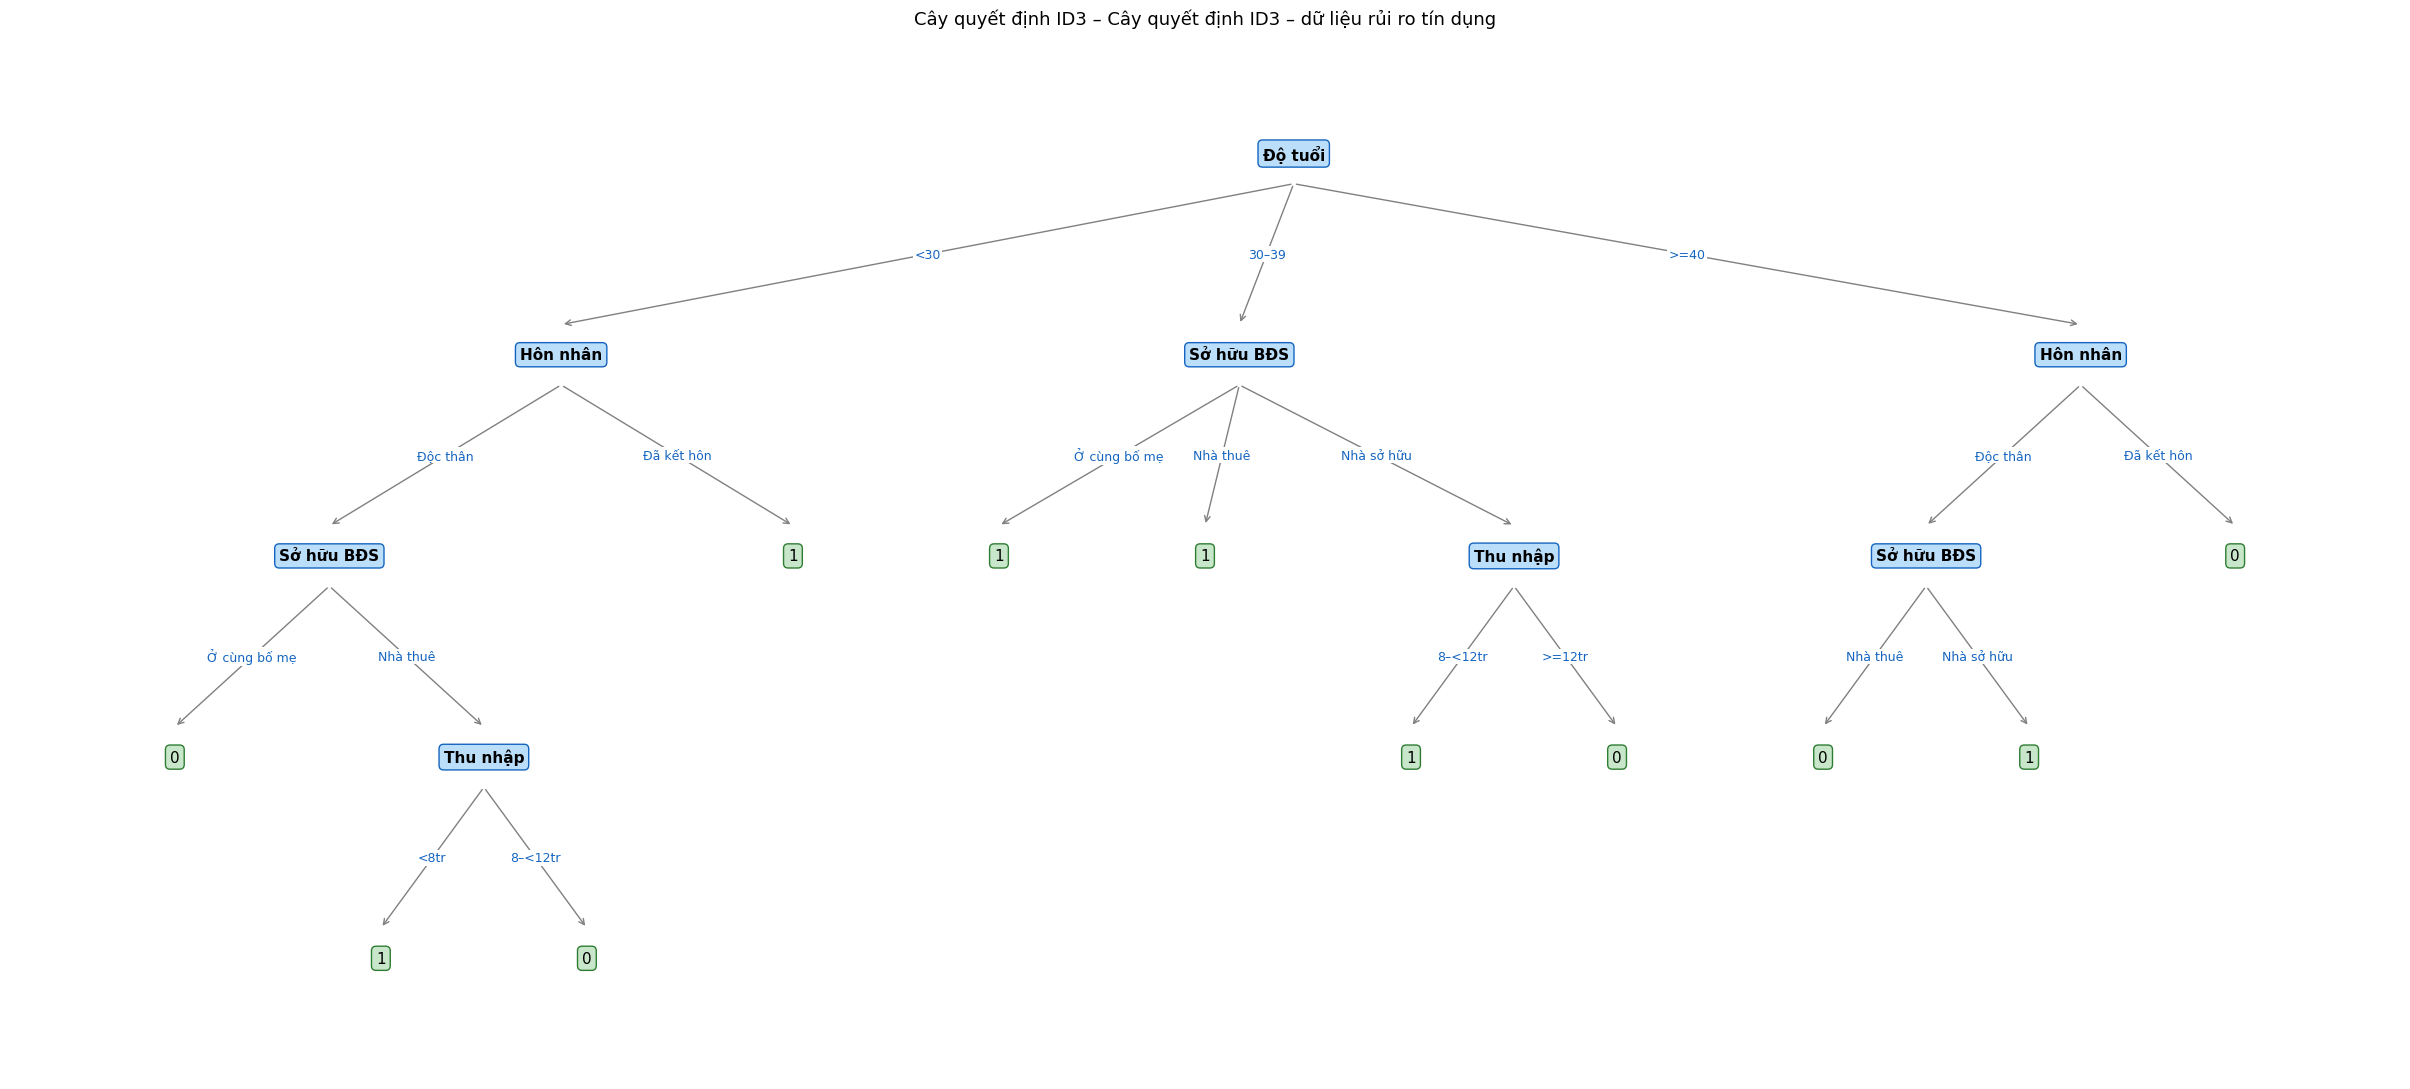

In [7]:
# ===== Vẽ cây bằng matplotlib =====
def count_leaves(node):
    return 1 if "label" in node else sum(count_leaves(c) for c in node["children"].values())

def depth_of(node):
    return 0 if "label" in node else 1 + max(depth_of(c) for c in node["children"].values())

def plot_tree_id3(tree, title):
    W, D = count_leaves(tree), depth_of(tree)
    fig, ax = plt.subplots(figsize=(max(8, 2.2 * W), 2.2 * (D + 1)))
    ax.axis("off")
    x_next = [0]

    def draw(node, depth):
        y = D - depth
        if "label" in node:
            x = x_next[0]; x_next[0] += 1
            ax.text(x, y, str(node["label"]), ha="center", va="center", fontsize=11,
                    bbox=dict(boxstyle="round", fc="#c8e6c9", ec="#2e7d32"))
            return x
        xs = []
        for v, child in node["children"].items():
            cx = draw(child, depth + 1)
            xs.append((cx, v))
        x = np.mean([c for c, _ in xs])
        for cx, v in xs:
            ax.annotate("", xy=(cx, y - 1 + 0.15), xytext=(x, y - 0.15),
                        arrowprops=dict(arrowstyle="->", color="gray"))
            ax.text((x + cx) / 2, y - 0.5, str(v), ha="center", va="center", fontsize=9,
                    color="#1565c0", bbox=dict(fc="white", ec="none", pad=1))
        ax.text(x, y, node["attr"], ha="center", va="center", fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round", fc="#bbdefb", ec="#1565c0"))
        return x

    draw(tree, 0)
    ax.set_xlim(-0.8, W - 0.2); ax.set_ylim(-0.6, D + 0.6)
    ax.set_title(title, fontsize=13)
    plt.tight_layout(); plt.show()

plot_tree_id3(tree, "Cây quyết định ID3 – Cây quyết định ID3 – dữ liệu rủi ro tín dụng")

### Bước 6: Tập luật IF–THEN

In [8]:
for i, (conds, label) in enumerate(extract_rules(tree), 1):
    print(f"Luật {i}: IF " + " AND ".join(conds) + f" THEN {TARGET} = {label}")

Luật 1: IF Độ tuổi = <30 AND Hôn nhân = Độc thân AND Sở hữu BĐS = Ở cùng bố mẹ THEN Rủi ro tín dụng = 0
Luật 2: IF Độ tuổi = <30 AND Hôn nhân = Độc thân AND Sở hữu BĐS = Nhà thuê AND Thu nhập = <8tr THEN Rủi ro tín dụng = 1
Luật 3: IF Độ tuổi = <30 AND Hôn nhân = Độc thân AND Sở hữu BĐS = Nhà thuê AND Thu nhập = 8–<12tr THEN Rủi ro tín dụng = 0
Luật 4: IF Độ tuổi = <30 AND Hôn nhân = Đã kết hôn THEN Rủi ro tín dụng = 1
Luật 5: IF Độ tuổi = 30–39 AND Sở hữu BĐS = Ở cùng bố mẹ THEN Rủi ro tín dụng = 1
Luật 6: IF Độ tuổi = 30–39 AND Sở hữu BĐS = Nhà thuê THEN Rủi ro tín dụng = 1
Luật 7: IF Độ tuổi = 30–39 AND Sở hữu BĐS = Nhà sở hữu AND Thu nhập = 8–<12tr THEN Rủi ro tín dụng = 1
Luật 8: IF Độ tuổi = 30–39 AND Sở hữu BĐS = Nhà sở hữu AND Thu nhập = >=12tr THEN Rủi ro tín dụng = 0
Luật 9: IF Độ tuổi = >=40 AND Hôn nhân = Độc thân AND Sở hữu BĐS = Nhà thuê THEN Rủi ro tín dụng = 0
Luật 10: IF Độ tuổi = >=40 AND Hôn nhân = Độc thân AND Sở hữu BĐS = Nhà sở hữu THEN Rủi ro tín dụng = 1
Luật 11

### Bước 7: Dự đoán cho mẫu mới

In [9]:
# Mẫu mới: khách hàng 45 tuổi, đã kết hôn, có nhà sở hữu, thu nhập 20 triệu
tuoi, thu_nhap = 45, 20_000_000
new_sample = {"Độ tuổi": nhom_tuoi(tuoi), "Hôn nhân": "Đã kết hôn",
              "Sở hữu BĐS": "Nhà sở hữu", "Thu nhập": nhom_thu_nhap(thu_nhap)}
print("Mẫu mới (đã rời rạc hóa):", new_sample)
print("Đường đi trên cây:")
predict_one(tree, new_sample, explain=True)

Mẫu mới (đã rời rạc hóa): {'Độ tuổi': '>=40', 'Hôn nhân': 'Đã kết hôn', 'Sở hữu BĐS': 'Nhà sở hữu', 'Thu nhập': '>=12tr'}
Đường đi trên cây:
  Độ tuổi = >=40
  Hôn nhân = Đã kết hôn
  => Nhãn dự đoán: 0


np.int64(0)

### Kiểm tra: độ chính xác trên tập huấn luyện

In [10]:
y_pred = predict(tree, data[ATTRS])
acc = np.mean(np.array(y_pred) == data[TARGET].values)
print(f"Độ chính xác trên tập huấn luyện: {acc:.2%}")

Độ chính xác trên tập huấn luyện: 100.00%


## Nhận xét
- **Độ tuổi** có Gain lớn nhất tại nút gốc (0.171) nên được chọn làm gốc. Tuy vậy, các Gain đều khá nhỏ, cho thấy không có thuộc tính nào tách dữ liệu thật rõ ràng.
- Bài này có nhiều trường hợp **bằng Gain**: ví dụ ở nhánh `30–39`, Sở hữu BĐS và Thu nhập cùng có Gain = 0.317. Theo quy ước, ta chọn thuộc tính đứng trước. Nếu chọn thuộc tính kia, cây sẽ có hình dạng khác nhưng vẫn phân loại đúng tập huấn luyện.
- Cây sâu tới 4 tầng và nhiều luật chỉ dựa trên 1–2 mẫu, ví dụ nhánh `<30 ∧ Độc thân ∧ Nhà thuê` phải chia tiếp theo Thu nhập. Đây là dấu hiệu **quá khớp (overfitting)**: cây học thuộc từng mẫu thay vì học quy luật chung.
- Cây đạt độ chính xác 100% trên tập huấn luyện. Nhưng với 15 mẫu và cây phức tạp như vậy, độ tin cậy khi dự đoán khách hàng mới không cao. Trong thực tế cần thêm dữ liệu, hoặc giới hạn độ sâu cây và cắt tỉa (pruning).
- Kết quả phụ thuộc vào cách chia nhóm tuổi và thu nhập. Nếu chia ngưỡng khác, Gain và cây sẽ thay đổi.